Import the necessary libraries and the dataset sourced from the MoleculeNet group. [1]

[1] Zhenqin Wu, Bharath Ramsundar, Evan N Feinberg, Joseph Gomes, Caleb
Geniesse, Aneesh S Pappu, Karl Leswing, and Vijay Pande. Moleculenet: a
benchmark for molecular machine learning. Chemical science, 9(2):513–530, 2018.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import rdkit, rdkit.Chem
import numpy as np

toxdata = pd.read_csv("https://github.com/whitead/dmol-book/raw/main/data/clintox.csv.gz")

get a molecule from the dataset and display it

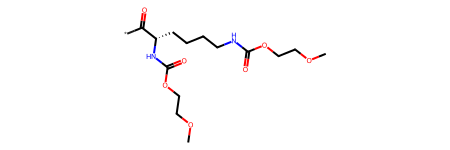

In [5]:
m = rdkit.Chem.MolFromSmiles(toxdata.smiles[0])
m

get all of the molecules and print the second molecule

[14:09:30] Explicit valence for atom # 0 N, 4, is greater than permitted
[14:09:30] Can't kekulize mol.  Unkekulized atoms: 9
[14:09:30] Can't kekulize mol.  Unkekulized atoms: 4
[14:09:30] Can't kekulize mol.  Unkekulized atoms: 4


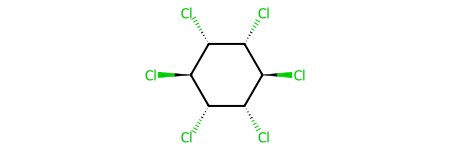

In [6]:
molecules = [rdkit.Chem.MolFromSmiles(smi) for smi in toxdata.smiles]
molecules[1]

count the amoutn of proper SMILE strings

In [7]:
valid_mol_idx = [bool(m) for m in molecules]
valid_mols = [m for m in molecules if m]
len(valid_mols)

1480

define the labels and count the data with a true value for FDA_APPROVED

In [8]:
y = toxdata[valid_mol_idx].FDA_APPROVED
y.value_counts()

,count
FDA_APPROVED,
1,1386
0,94


give descriptors to the data based on the SMILES

In [9]:
from rdkit.Chem import Descriptors
vals = [Descriptors.CalcMolDescriptors(x) for x in valid_mols]
X = pd.DataFrame(vals)
X

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,11.642626,11.642626,0.102432,-0.606208,0.467548,12.000000,333.361,308.161,333.166176,133,...,0,0,0,0,0,0,0,0,1,0
1,5.881173,5.881173,0.436728,-0.436728,0.597604,55.500000,290.832,284.784,287.860066,72,...,0,0,0,0,0,0,0,0,0,0
2,9.960733,9.960733,2.109169,-2.500926,0.346644,19.428571,208.122,200.058,208.023014,82,...,0,0,0,0,0,0,0,0,0,0
3,11.987806,11.987806,0.143734,-0.153791,0.260032,17.476190,282.347,264.203,282.146964,106,...,0,0,0,0,0,0,0,0,0,0
4,7.011424,7.011424,0.310967,0.310967,0.257572,13.120000,342.443,316.235,342.204479,132,...,0,0,0,0,0,0,0,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1475,8.740741,8.740741,3.129630,-3.129630,0.342499,6.000000,78.099,76.083,77.977320,24,...,0,0,0,0,0,0,0,0,0,0
1476,8.500000,8.500000,2.000000,-2.000000,0.376008,2.666667,79.865,79.865,79.937776,16,...,0,0,0,0,0,0,0,0,0,0
1477,8.375000,8.375000,0.125000,0.125000,0.371618,3.000000,81.389,81.389,79.924057,8,...,0,0,0,0,0,0,0,0,0,0
1478,8.604167,8.604167,4.694444,-4.694444,0.334872,12.000000,100.457,99.449,99.956336,32,...,0,0,0,0,0,0,0,0,0,0


**ASSIGNMENT:** Generate a ML model that classifies the molecules according to their FDA approval status and evaluate its performances.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# drop the NaN values
X.dropna(inplace = True, axis = 1)
len(X), len(X.columns)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)
scaler = preprocessing.StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

lr = LogisticRegression()
lr.fit(X = X_train, y = y_train)

y_pred = lr.predict(X_test)
print("Accuracy score: " + str(accuracy_score(y_test, y_pred)))
print("\nConfusion matrix: \n" + str(confusion_matrix(y_test, y_pred)))
print("\nClassification report: \n" + str(classification_report(y_test, y_pred)))

Accuracy score: 0.9488752556237219

Confusion matrix: 
[[ 12  19]
 [  6 452]]

Classification report: 
              precision    recall  f1-score   support

           0       0.67      0.39      0.49        31
           1       0.96      0.99      0.97       458

    accuracy                           0.95       489
   macro avg       0.81      0.69      0.73       489
weighted avg       0.94      0.95      0.94       489

